# Comparación de Modos de Coordenadas AXITRA

Este notebook verifica que la lógica de conversión de coordenadas en `kdellipspy` sea correcta comparando dos sintéticos:
1. **Modo Lat/Lon**: AXITRA recibe grados y hace la proyección internamente.
2. **Modo Cartesiano**: Nosotros convertimos Lat/Lon a metros (Norte/Este) usando nuestra clase `UTMProjection` y se los pasamos a AXITRA.

Si los sismogramas coinciden, nuestra geometría está bien construida.

In [12]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Agregar raíz
project_root = str(Path('..').resolve())
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Incluir AXITRA directamente al path (está en kdellipspy/axitra/src)
axitra_dir = str((Path('.') / 'axitra' / 'src').resolve())
print(f"AXITRA directory added to path: {axitra_dir}")
sys.path.insert(0, axitra_dir)

from kdellipspy.core.geometry import UTMProjection
from axitra import Axitra,moment

AXITRA directory added to path: /home/alex/KDEllipsPy/kdellipspy/axitra/src


In [13]:
# Definición de modelo de velocidades y geometría básica (similar a example.ipynb)

# 2 layers: thickness (or top), Vp, Vs, rho, Qp, Qs
# OJO: La última capa debe ser el semiespacio infinito y llevar "thickness" = 0.
model = np.array([[1000., 5000., 2886., 2700., 1000., 500.],
                  [0., 6000., 3886., 2700., 1000., 500.]])
# 2 sources
# index, lat, lon, depth
sources=np.array([[1, 45.100, 2.000, 5000.000],
                  [2, 45.200, 2.000, 5000.000]])
# Coordenadas geográficas base
# 5 receivers with geographical coordinates
# index, lat, lon, depth
stations=np.array(
        [[1, 45.000, 2.000, 0.000],
         [2, 46.000, 1.000, 0.000],
         [3, 46.000, 3.000, 0.000],
         [4, 44.000, 1.000, 0.000],
         [5, 44.000, 3.000, 0.000]])

  with            2 source(s) and            5 receiver(s) and            2 layer(s)
 ................. with a free surface at depth Z=0
 distance unit is detected as meter
freq   479/ 1000 iter=      544

 running axitra Moment Version 20212403.1
 running openMp on            6  threads


freq   995/ 1000 iter=     1099 Done
/home/alex/KDEllipsPy/kdellipspy/axitra/src/axitra ran sucessfully
 Moment (Nm):   7.5000000000000000E+020
 Moment (Dyne.cm):   7.5000000000000002E+027
 Moment (Nm):   7.5000000000000000E+020
 Moment (Dyne.cm):   7.5000000000000002E+027


 running openMp on            6  threads


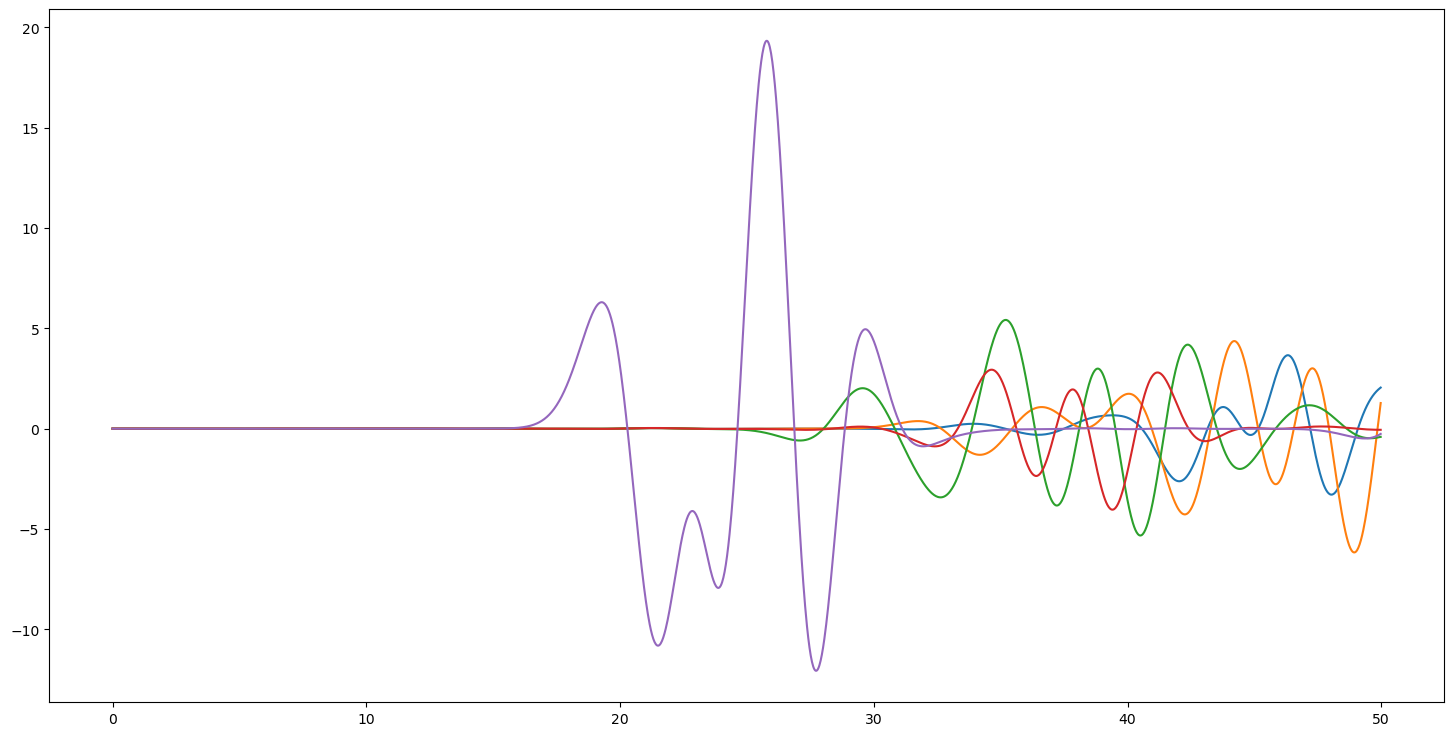

In [14]:
# MODO 1: Lat/Lon verdadero (calculado internamente por AXITRA)

# Instancia de axitra
ap = Axitra(model, stations,sources, 
               fmax=20.0, duration=50., xl=0., 
               latlon=True, axpath=axitra_dir)
ap = moment.green(ap)

# history of source
hist = np.array([[1,7.5e20,148.0,84.0,-47.0,0.,0.,20.0],
                 [2,7.5e20,148.0,84.0,-47.0,0.,0.,20.0]])
t, sx, sy, sz = moment.conv(ap,hist,source_type=1,t0=2,unit=1)
plt.figure(figsize=(18, 9))
ier=plt.plot(t,sx[1,:],t,sx[2,:],t,sx[3,:],t,sx[4,:],t,sx[0,:],)


 running axitra Moment Version 20212403.1
 running openMp on            6  threads


  with            2 source(s) and            5 receiver(s) and            2 layer(s)
 ................. with a free surface at depth Z=0
 distance unit is detected as meter
freq   997/ 1000 iter=     1101 Done
/home/alex/KDEllipsPy/kdellipspy/axitra/src/axitra ran sucessfully
 Moment (Nm):   7.5000000000000000E+020
 Moment (Dyne.cm):   7.5000000000000002E+027
 Moment (Nm):   7.5000000000000000E+020
 Moment (Dyne.cm):   7.5000000000000002E+027


 running openMp on            6  threads


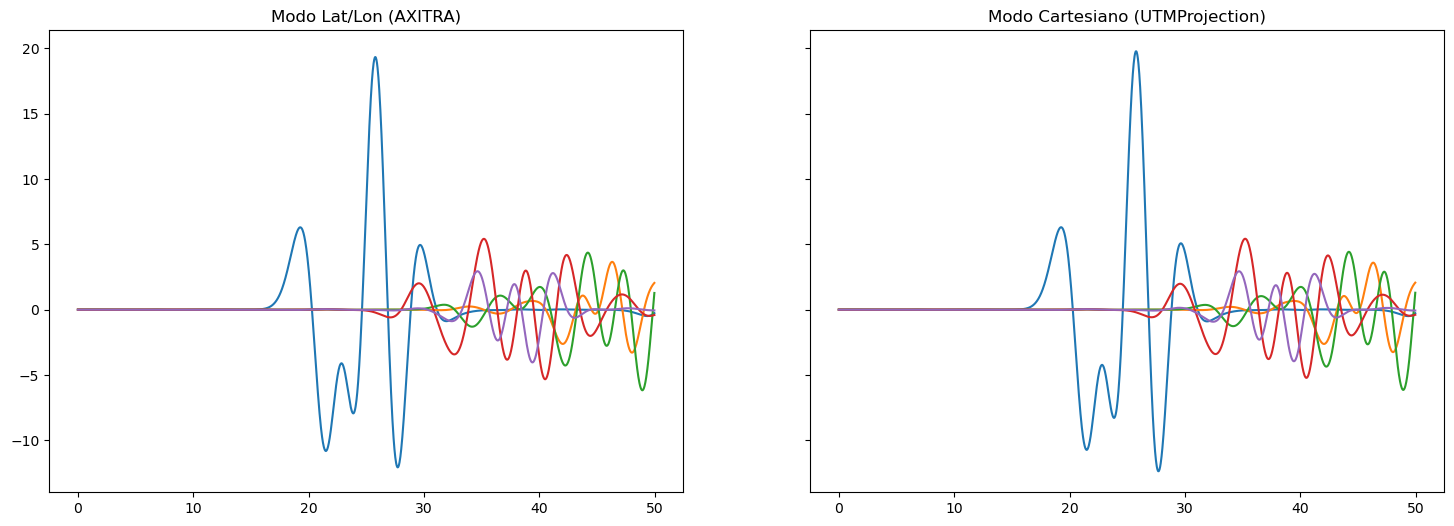

Diferencia máxima en componente X: 5.66e-01 metros
ADVERTENCIA: Hay discrepancias significativas.


In [15]:
# MODO 2: Cartesiano (nosotros hacemos la proyección)

# Usamos el primer receptor como referencia (0,0) para la proyección local
ref_lat, ref_lon = stations[0, 1], stations[0, 2]
proj = UTMProjection(ref_lat, ref_lon)
e0, n0 = proj.latlon_to_xy(ref_lat, ref_lon)

# Convertir estaciones a metros (Norte, Este)
stations_local = stations.copy()
for i in range(len(stations)):
    ei, ni = proj.latlon_to_xy(stations[i, 1], stations[i, 2])
    stations_local[i, 1] = ni - n0  # North
    stations_local[i, 2] = ei - e0  # East

# Convertir fuentes a metros
sources_local = sources.copy()
for i in range(len(sources)):
    ei, ni = proj.latlon_to_xy(sources[i, 1], sources[i, 2])
    sources_local[i, 1] = ni - n0  # North
    sources_local[i, 2] = ei - e0  # East

# Instancia de axitra en modo cartesiano
ap2 = Axitra(model, stations_local, sources_local, 
                fmax=20.0, duration=50., xl=0., 
                latlon=False, axpath=axitra_dir)
ap2 = moment.green(ap2)

t2, sx2, sy2, sz2 = moment.conv(ap2, hist, source_type=1, t0=2, unit=1)

# Comparación visual
fig, ax = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
ax[0].plot(t, sx.T)
ax[0].set_title("Modo Lat/Lon (AXITRA)")
ax[1].plot(t2, sx2.T)
ax[1].set_title("Modo Cartesiano (UTMProjection)")
plt.show()

# Verificar diferencia
diff = np.max(np.abs(sx - sx2))
print(f"Diferencia máxima en componente X: {diff:.2e} metros")
if diff < 1e-3:
    print("¡ÉXITO! Las conversiones son consistentes.")
else:
    print("ADVERTENCIA: Hay discrepancias significativas.")
